# <span style="color: red; font-weight:bold">  Multivariate Regime-Conditional Simulator 
## <span style="color: red; font-weight:bold"> Simulated World Project.
### <span style="color: brown; font-weight:bold"> Part 1.2: Synthetic Worlds. Regime SImulation, Factor Score

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from scipy import stats 
from sklearn.neighbors import KernelDensity

In [4]:
# Load data
data = pd.read_csv("project_DATA/features_for_part_1_2_df.csv", index_col="Date", parse_dates=True)
df = data.copy(deep=True)

In [5]:
################ Check if any NaN exists in the entire DataFrame ##########################
def check_nan(df):
    nan_mask = df.isna()
    has_nan = nan_mask.any().any()
    print(f"Does the DataFrame contain any NaN values? {has_nan}")
    if has_nan:
        nan_counts = nan_mask.sum()
        print(f"Count of NaN values per column:\n{nan_counts[nan_counts > 0]}")
###########################################################################################

In [6]:
check_nan(df)
# Clean
df = df.dropna()

Does the DataFrame contain any NaN values? False


In [7]:
# Prepare Target & Regimes
# Forward returns (prediction target)
df.rename(columns={'target':'return'}, inplace=True)
df['fwd_return'] = df['return'].shift(-1)

In [8]:
# Create Market State Variables for GaussianHMM

# 1. Shock
df['log_ret'] = np.log1p(df['return'])

# 2. Volatility
# shift(1) means: Regime is then fully known at decision time. Zero leakage concerns
df['realized_vol'] = (df['return'].ewm(span=20).std().shift(1))

# 3. VIX
df['VIX_level'] = df['VIX_indx_close']
df['VIX_change'] = np.log(df['VIX_indx_close']).diff()

# 4. Volume
df['vol_z'] = (
    (df['Volume'] - df['Volume'].rolling(20).mean()) /
    df['Volume'].rolling(20).std()
).shift(1)

df = df.dropna()


In [9]:
hmm_features_df = df.copy(deep=True)

In [10]:
hmm_features_df.shape

(6468, 66)

In [11]:
# List of columns to define regime
state_cols = ['log_ret','realized_vol', 'VIX_level', 'VIX_change', 'vol_z']

In [12]:
# Scale
scaler = StandardScaler()
X_state = scaler.fit_transform(hmm_features_df[state_cols].values)

In [13]:
# Run the model
model = GaussianHMM(
    n_components=3,           # 3 regimes
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model.fit(X_state)

,n_components,3
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,42


In [14]:
# Predict the regimes
hidden_states = model.predict(X_state)
# Create Regime Factor
hmm_features_df['hmm_regime'] = hidden_states

In [15]:
# Regime stats
hmm_summary = hmm_features_df.groupby('hmm_regime')[state_cols].mean()
print(hmm_summary)


             log_ret  realized_vol  VIX_level  VIX_change     vol_z
hmm_regime                                                         
0           0.000716      0.006079  13.298359   -0.000108 -0.021610
1           0.000107      0.009715  19.756116    0.000408  0.049027
2          -0.000405      0.019904  32.397571   -0.001195  0.065138


In [16]:
# Check persistence
print(model.transmat_)
# Save the matrix. We'll use it to simulate regimes

HMM_matrix = model.transmat_
# Save to file
np.save('project_DATA/HMM_real_world_transition_matrix', HMM_matrix)

[[9.79538250e-01 2.04617504e-02 1.06263579e-90]
 [1.80061367e-02 9.72568467e-01 9.42539597e-03]
 [1.87665236e-58 2.16112139e-02 9.78388786e-01]]


In [17]:
# HMM regimes are unlabeled. Lets label them
mapping = {0:'calm',1:'transition',2:'stress'}
hmm_features_df['regime_name'] = hmm_features_df['hmm_regime'].map(mapping)

In [18]:
hmm_features_df.shape

(6468, 68)

In [18]:
#===============================================================================================================

## <span style="color: green; font-weight:bold"> Visualize the Close prices for each regime 

In [19]:
# Load data
close_data = pd.read_csv("project_DATA/CLOSE_data_for_part_1_2.csv", index_col="Date", parse_dates=True)
close_df = close_data.copy(deep=True)

In [20]:
hmm_regime_df = hmm_features_df[['hmm_regime']]

In [21]:
# Align the data (make sure dates match)
combined_df = pd.concat([close_df, hmm_regime_df], axis=1).dropna()

In [62]:
def all_data_viz(combined_df):
    # Create the plot
    plt.figure(figsize=(15, 8))
    
    # Scatter plot with colors based on regime
    colors = {0: 'blue', 1: 'green', 2: 'red'}  
    for regime in combined_df['hmm_regime'].unique():
        mask = combined_df['hmm_regime'] == regime

        if regime == 0:
            regime_name = "calm"
        elif regime == 1:
            regime_name = "transition"
        else:
            regime_name = "stress"    

       
        plt.scatter(combined_df.index[mask], 
                    combined_df['Close'][mask], 
                    c=colors.get(regime, 'gray'), 
                    label=f'Regime {regime_name}', 
                    s=10, alpha=0.7)
    
    plt.title('Close Price S&P500 2000-2025 with Hidden Markov Model (HMM) Regimes discovered. The Real World.', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('S&P500. Daily Close Price', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

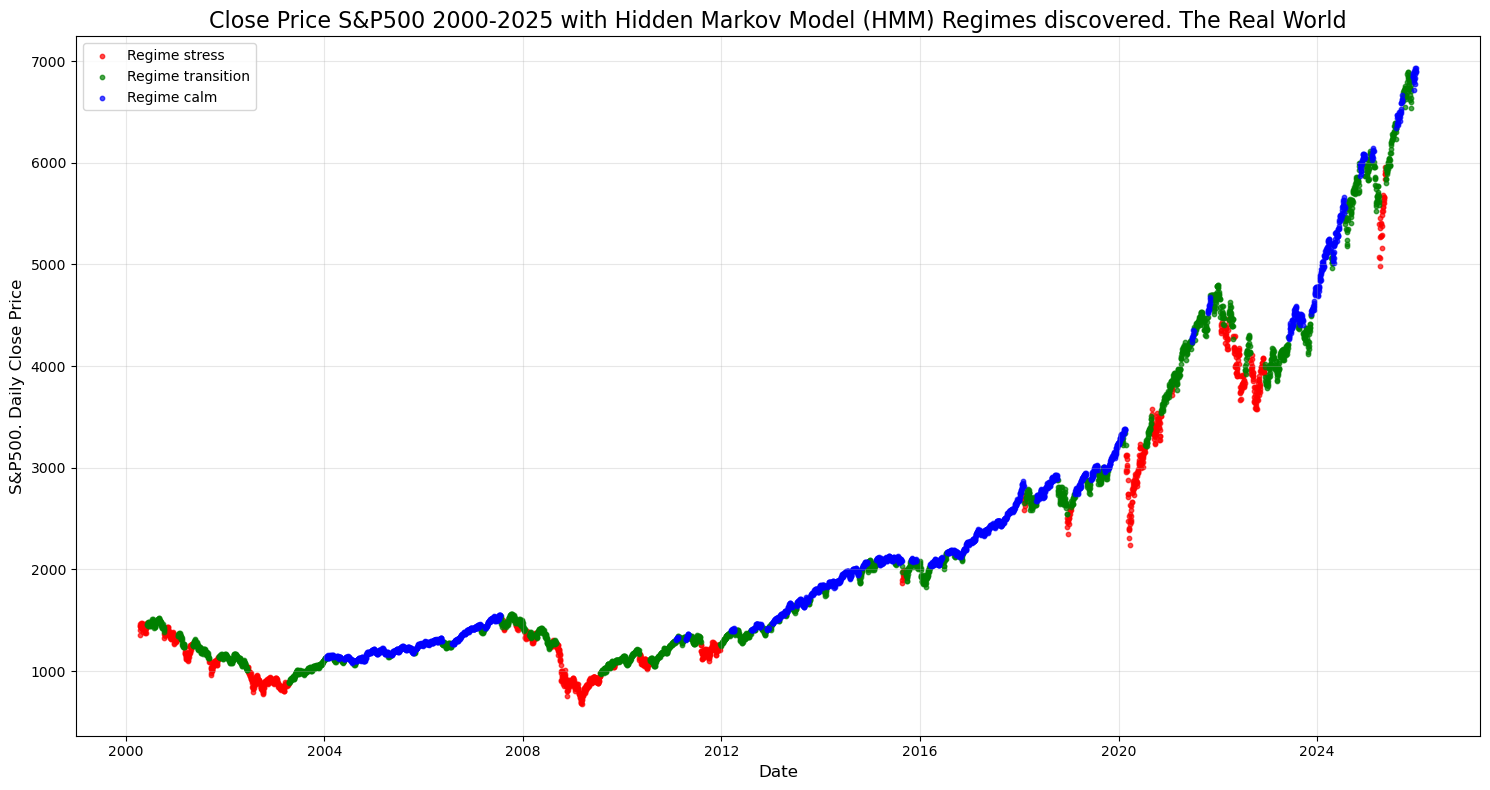

In [33]:
all_data_viz(combined_df)

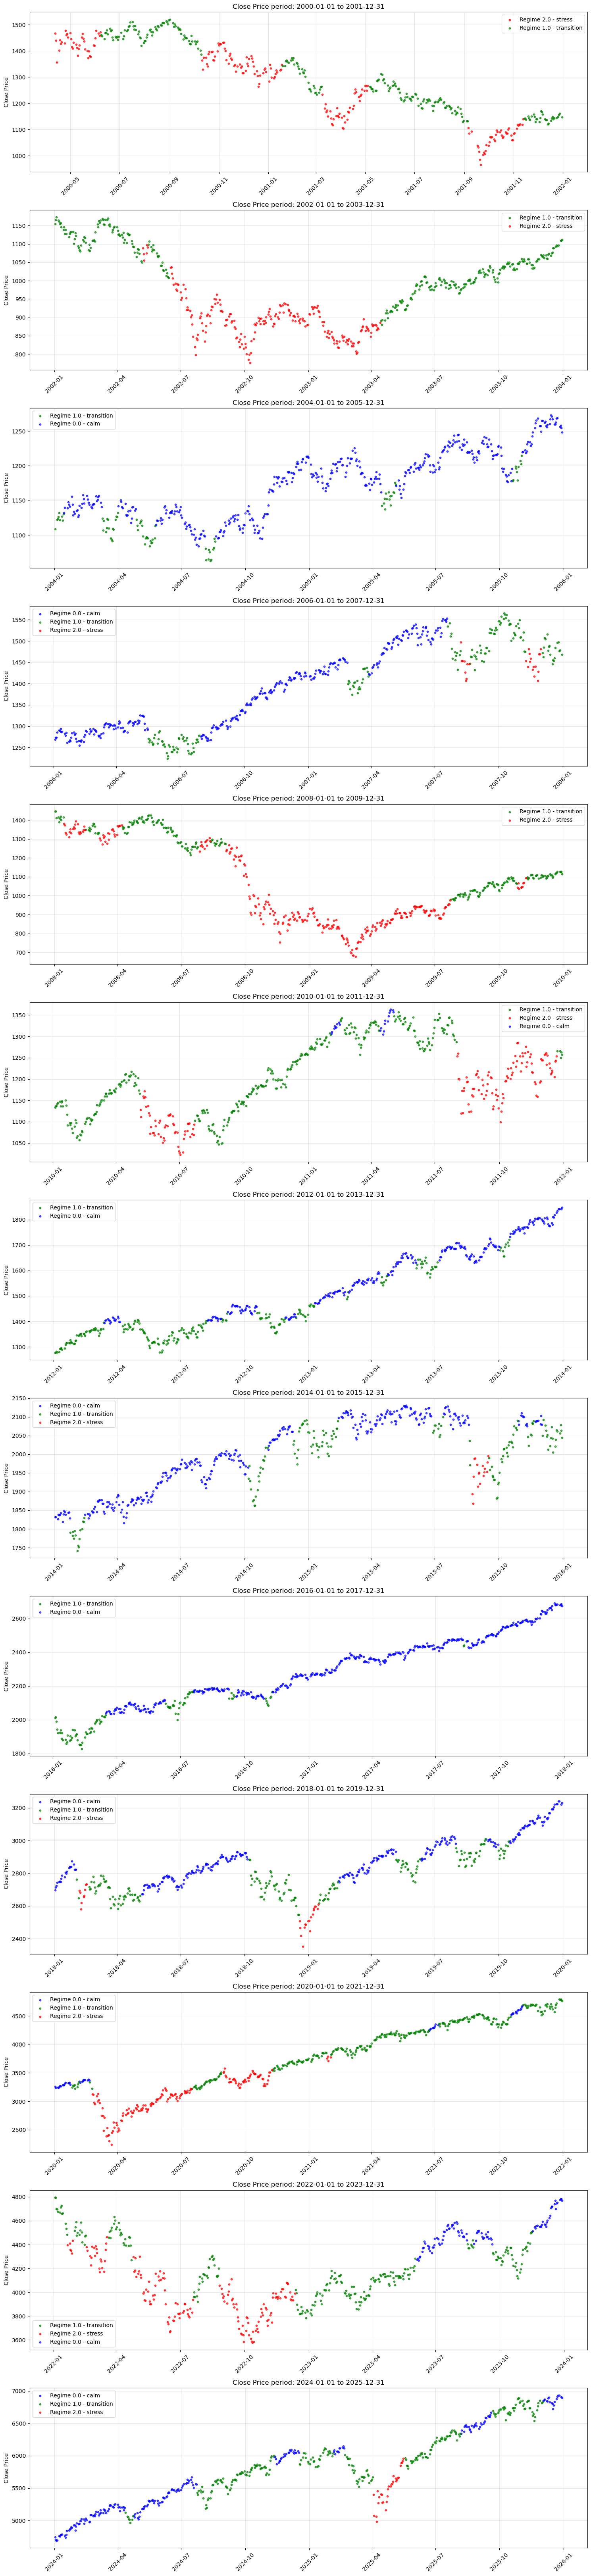

In [34]:
# Define your date ranges
date_ranges = [
    ('2000-01-01', '2001-12-31'),
    ('2002-01-01', '2003-12-31'),
    ('2004-01-01', '2005-12-31'),
    ('2006-01-01', '2007-12-31'),
    ('2008-01-01', '2009-12-31'),
    ('2010-01-01', '2011-12-31'),
    ('2012-01-01', '2013-12-31'),
    ('2014-01-01', '2015-12-31'),
    ('2016-01-01', '2017-12-31'),
    ('2018-01-01', '2019-12-31'),
    ('2020-01-01', '2021-12-31'),
    ('2022-01-01', '2023-12-31'),
    ('2024-01-01', '2025-12-31')
]

# Create subplots
n_plots = len(date_ranges)
fig, axes = plt.subplots(n_plots, 1, figsize=(15, 5*n_plots))

colors = {0: 'blue', 1: 'green', 2: 'red'}

for idx, (start_date, end_date) in enumerate(date_ranges):
    # Filter data for this date range
    mask = (combined_df.index >= start_date) & (combined_df.index <= end_date)
    df_range = combined_df[mask]
    
    if len(df_range) > 0:
        ax = axes[idx]
        
        # Plot each regime
        for regime in df_range['hmm_regime'].unique():
            regime_mask = df_range['hmm_regime'] == regime
            if regime == 0:
                regime_name = "calm"
            elif regime == 1:
                regime_name = "transition"
            else:
                regime_name = "stress" 
                
            ax.scatter(df_range.index[regime_mask], 
                      df_range['Close'][regime_mask], 
                      c=colors.get(regime, 'gray'), 
                      label=f'Regime {regime} - {regime_name}', 
                      s=10, alpha=0.7)
        # Add legend
        ax.legend()
            
        ax.set_title(f'Close Price period: {start_date} to {end_date}', fontsize=12)
        ax.set_ylabel('Close Price', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        
plt.tight_layout()
plt.show()

In [35]:
#===============================================================================================================

## <span style="color: green; font-weight:bold"> Vetting Features - Factors 

In [36]:
# Copy 
vet_features_df = hmm_features_df.copy(deep=True)

In [37]:
# Helper Functions
# IC - Information Coefficient - function (Spearman)
    #---------------------------------------
    # IC(feature, fwd_return | regime=calm)
    # IC(feature, fwd_return | regime=stress)
    #---------------------------------------
def ic(x, y):
    return pd.Series(x).corr(pd.Series(y), method='spearman')

# Lead-lag IC
def lead_lag_ic(feature, returns, lags=range(-5,6)):
    out={}
    for lag in lags:
        shifted_ret = returns.shift(-lag)
        out[lag] = ic(feature, shifted_ret)
    return out

In [38]:
vet_features_df.shape

(6468, 68)

In [39]:
check_nan(vet_features_df)
# Clean
vet_features_df = vet_features_df.dropna()

Does the DataFrame contain any NaN values? False


In [40]:
# List of factors to exlude from vettting
col_to_exclude = [
    'Volume',
 'return',
 'fwd_return',
 'log_ret',
 'realized_vol',
 'VIX_level',
 'VIX_change',
 #'VIX_indx_close',
 'vol_z',
 'hmm_regime',
 'regime_name'    
]
# Vetting factors
col_to_keep = [col for col in vet_features_df.columns if col not in col_to_exclude]

In [41]:
# Feature Vetting Function
def vet_feature(df, feature_col, n_boot=500, window=126):
    
#====================================================    
    def rolling_spearman_ic(f, r, window):
        
        ic_s = []
        for i in range(len(f)):
            if i < window:
                ic_s.append(np.nan)
                continue
    
            f_win = f.iloc[i-window:i]
            r_win = r.iloc[i-window:i]

            #-------------------------
            if f_win.nunique() < 2 or r_win.nunique() < 2:
                ic = np.nan
            else:
                ic = f_win.corr(r_win, method="spearman")
            
            ic_s.append(ic)
                
            # ic = f_win.corr(r_win, method="spearman")
            # ic_s.append(ic_s)    
            
        return pd.Series(ic_s, index=f.index)
#====================================================
    
    f = df[feature_col]
    r = df["fwd_return"]
    
    # align
    paired = pd.concat([f,r],axis=1).dropna()
    paired.columns=["f","r"]

    f = paired["f"]
    r = paired["r"]

    regime = df.loc[paired.index, "hmm_regime"]
    vol_z  = df.loc[paired.index, "vol_z"]
    
    # --- Overall IC
    ic_all = ic(f, r)
    
#----------------------------------------------------------------------------------
    # ---- IC (Information Coefficient) significance test
    n = len(paired)

    if n>3 and abs(ic_all)<1:
        t_stat = ic_all*np.sqrt((n-2)/(1-ic_all**2))
        p_value = 2*(1-stats.t.cdf(abs(t_stat),df=n-2))
    else:
        t_stat,p_value = np.nan,np.nan
#----------------------------------------------------------------------------------
    
# ---- Rolling IC.
    # Measures time stability.

    ric = rolling_spearman_ic(f, r, window)
    ric = ric.dropna()

    if len(ric)==0:
        stability_ric = np.nan
    else:
        mean_ric = ric.mean()
        std_ric = ric.std()
        # Stability metric. Higher = more stable.
        stability_ric = abs(mean_ric)/(std_ric+1e-6)
#----------------------------------------------------------------------------------
    
# --_- Bootstrap IC.
    # Measures statistical reliability.
    
    ics = []
    for _ in range(n_boot):
        sample = paired.sample(len(paired),replace=True)
        icc = sample["f"].corr(sample["r"], method="spearman")
        if np.isnan(icc):
            continue
        ics.append(icc)

    bic = np.array(ics)
    
    mean_bic = bic.mean()
    ci_low, ci_high = np.percentile(bic, [5,95])
    interval_ci = ci_high - ci_low
    
#----------------------------------------------------------------------------------
    
# --- Regime ICs
    mask_calm = regime == 0        # calm
    mask_transition = regime == 1  # transition is ignored for now
    '''
    Transition regimes are often noise/mixed state.
    Option A — Ignore.Just remove it.
    Option B — We can use it as stability check:
    ic_transition = ic(f[mask_transition], r[mask_transition])   
    If transition IC is wildly different from calm/stress --> instability flag.
    '''
    mask_stress = regime == 2      # stress

    # Minimum sample per regime rule
    min_n = 50
    if mask_calm.sum() >= min_n:
        ic_calm = ic(f[mask_calm], r[mask_calm])
    else:
        ic_calm = np.nan

    if mask_stress.sum() >= min_n:
        ic_stress = ic(f[mask_stress], r[mask_stress])
    else:
        ic_stress = np.nan

    if not np.isnan(ic_calm) and not np.isnan(ic_stress):
        regime_gap = abs(ic_calm - ic_stress)
    else:
        regime_gap = np.nan

    #print(f'mask_calm.sum(): {mask_calm.sum()}')
    #print(f'mask_stress.sum(): {mask_stress.sum()}')
    #print(f'===================================')
    
#----------------------------------------------------------------------------------
    
# --- Lead-lag IC
    ll = lead_lag_ic(f, r)
    peak_lag = max(ll, key=lambda k: abs(ll[k]))

#----------------------------------------------------------------------------------
    
# --- Volume conditioning (collider test)
    high_vol = vol_z > vol_z.median()
    low_vol = vol_z <= vol_z.median()    
    ic_high_vol = ic(f[high_vol], r[high_vol])
    ic_low_vol = ic(f[low_vol], r[low_vol])

    vol_sensitivity = abs(ic_high_vol - ic_low_vol)

# --- Extreme regime dependence
    # A factor that flips by regime is not stable alpha — it’s conditional behavior.
    gap_IC = regime_gap > abs(ic_all)  

    return {
        "ic_all": ic_all,                        # 2
        "ic_calm": ic_calm,
        "ic_stress": ic_stress,
        "regime_gap": regime_gap,
        "peak_lag": peak_lag,
        "vol_sensitivity": vol_sensitivity,
        "gap_gt_ic": gap_IC,
        "t-significance_test": t_stat,
        "abs.t-significance_test": abs(t_stat),
        "p_value": p_value,
        "stability_metric": stability_ric,       # 1
        "bootstrap_IC_mean": mean_bic,           # 3
        "ci_contains_zero":(ci_low<=0<=ci_high), # If TRUE → weak feature.
        "bootstrap_IC_interval": interval_ci
    }

In [42]:
# Run on All Features Vetting
feature_cols = col_to_keep.copy()
results = []

for col in feature_cols:
    res = vet_feature(vet_features_df, col)
    res["feature"] = col
    results.append(res)

results_df = pd.DataFrame(results)

In [43]:
# Factors Scoring
robust_score_df = results_df.copy(deep=True)

In [44]:
robust_score_df.shape

(58, 15)

In [45]:
'''
Metric Combo:
|IC|
× rolling stability
× CI tightness
'''
# Robust Factor Score - Option 3
robust_score_df["robust_score_3"] = (
    robust_score_df["bootstrap_IC_mean"].abs()
    * robust_score_df["stability_metric"]
    * robust_score_df["bootstrap_IC_interval"]**(-1)
)

In [46]:
# option - Weights for features
robust_score_df['weight_3'] = robust_score_df['robust_score_3'].clip(lower=0)

In [47]:
#========= PRO Factor Score ==================#

In [48]:
# Robust Factor Score - Option 4
'''
A realistic composite score:
score = |𝐼𝐶∣**a × Stability**b × Reliability**c × RegimeRobustness**d × LiquidityRobustness**e
'''
def factor_score(row, a=1, b=1.5, c=1, d=1, e=0.5):
    strength = abs(row["bootstrap_IC_mean"])**a  
   
    stability = (
        row["stability_metric"] if row["stability_metric"]>0 else 0
    )**b
    
    reliability = (1/(row["bootstrap_IC_interval"]+1e-6)
    )**c

    regime = (1/(1+row["regime_gap"])
    )**d

    liquidity = (1/(1+row["vol_sensitivity"])
    )**e

    return (
        strength
        * stability
        * reliability
        * regime
        * liquidity
    )

robust_score_df["pro_score"] = robust_score_df.apply(factor_score, axis=1)
robust_score_df = robust_score_df.sort_values("pro_score", ascending=False)

In [49]:
# Fitering Sorting Metrics-Factors data set 
robust_score_df_sorted = robust_score_df[['feature', 'pro_score', 'robust_score_3', 'ic_all', 'ic_calm', 'ic_stress', 'regime_gap', 'vol_sensitivity',
                 'stability_metric', 'bootstrap_IC_mean', 'bootstrap_IC_interval','ci_contains_zero', 'gap_gt_ic']] \
    .sort_values("pro_score", ascending=False).reset_index().drop(columns='index')

In [50]:
robust_score_df_sorted.shape

(58, 13)

In [51]:
robust_score_df_sorted

,feature,pro_score,robust_score_3,ic_all,ic_calm,ic_stress,regime_gap,vol_sensitivity,stability_metric,bootstrap_IC_mean,bootstrap_IC_interval,ci_contains_zero,gap_gt_ic
0,RSI_7_norm,2.288127,2.037878,-0.056772,-0.082330,-0.049543,0.032787,0.034777,1.391535,-0.057212,0.039066,False,False
1,RSI_14_norm,1.870970,1.643392,-0.048241,-0.079805,-0.041717,0.038087,0.041967,1.455437,-0.047761,0.042299,False,False
2,price_vs_EMA20,1.622433,1.435035,-0.044146,-0.066322,-0.044277,0.022045,0.032597,1.378795,-0.044276,0.042541,False,False
3,price_vs_EMA10,1.411629,1.345246,-0.050070,-0.064675,-0.050893,0.013782,0.021256,1.155797,-0.050432,0.043330,False,False
4,price_vs_SMA50,1.368139,1.138493,-0.032620,-0.058681,-0.036630,0.022052,0.036608,1.563794,-0.032899,0.045188,False,False
5,BB_position,1.362533,1.337038,-0.047682,-0.071430,-0.035603,0.035827,0.042795,1.161985,-0.048197,0.041887,False,False
6,high_close_ratio,1.244761,1.289867,0.059749,0.079496,0.085627,0.006132,0.007601,0.949948,0.060025,0.044206,False,False
7,price_vs_SMA20,1.104468,1.027222,-0.040647,-0.063137,-0.036647,0.026491,0.037935,1.264372,-0.040491,0.049839,False,False
8,VIX_indx_close,1.068365,0.889143,0.029410,0.068082,0.066273,0.001809,0.037213,1.502979,0.027781,0.046961,False,False
9,ROC_10,1.035916,1.027313,-0.041829,-0.049404,-0.035603,0.013801,0.033933,1.080590,-0.042236,0.044427,False,False


In [52]:
# Consider top tier factors
pro_score_df = robust_score_df_sorted.loc[0:len(robust_score_df_sorted)*0.7]
pro_score_df.to_csv("project_DATA/_pro_score_df.csv")

In [53]:
pro_score_df.set_index('feature', inplace=True)
pro_score_df.index.name = 'factors'

In [54]:
pro_score_df.shape

(41, 12)

In [55]:
pro_score_df

,pro_score,robust_score_3,ic_all,ic_calm,ic_stress,regime_gap,vol_sensitivity,stability_metric,bootstrap_IC_mean,bootstrap_IC_interval,ci_contains_zero,gap_gt_ic
factors,,,,,,,,,,,,
RSI_7_norm,2.288127,2.037878,-0.056772,-0.082330,-0.049543,0.032787,0.034777,1.391535,-0.057212,0.039066,False,False
RSI_14_norm,1.870970,1.643392,-0.048241,-0.079805,-0.041717,0.038087,0.041967,1.455437,-0.047761,0.042299,False,False
price_vs_EMA20,1.622433,1.435035,-0.044146,-0.066322,-0.044277,0.022045,0.032597,1.378795,-0.044276,0.042541,False,False
price_vs_EMA10,1.411629,1.345246,-0.050070,-0.064675,-0.050893,0.013782,0.021256,1.155797,-0.050432,0.043330,False,False
price_vs_SMA50,1.368139,1.138493,-0.032620,-0.058681,-0.036630,0.022052,0.036608,1.563794,-0.032899,0.045188,False,False
BB_position,1.362533,1.337038,-0.047682,-0.071430,-0.035603,0.035827,0.042795,1.161985,-0.048197,0.041887,False,False
high_close_ratio,1.244761,1.289867,0.059749,0.079496,0.085627,0.006132,0.007601,0.949948,0.060025,0.044206,False,False
price_vs_SMA20,1.104468,1.027222,-0.040647,-0.063137,-0.036647,0.026491,0.037935,1.264372,-0.040491,0.049839,False,False
VIX_indx_close,1.068365,0.889143,0.029410,0.068082,0.066273,0.001809,0.037213,1.502979,0.027781,0.046961,False,False


# How to treat ci_contains_zero and gap_gt_ic. 

    🔹 ci_contains_zero
    Means:
    Bootstrap CI includes 0 → IC may be noise
    This is a statistical reliability flag.
    It does NOT automatically mean useless.
    It means uncertain.

    🔹 gap_gt_ic
    regime_gap > |ic_all|
    Meaning:
    Regime dependence stronger than overall signal
    This is a stability / causality flag.
    This one is actually more dangerous than CI.
    A factor that flips by regime is not stable alpha — it’s conditional behavior.


## Decision Table      
    | ci_contains_zero | gap_gt_ic | Action |
    |------------------|----------|--------|
    | False            | False    | KEEP (strong & stable) |
    | True             | False    | PENALIZE (weak evidence but stable) |
    | False            | True     | PENALIZE HEAVILY or regime-split |
    | True             | True     |  DROP |


    (False, True) → Regime-dependent
    Use as regime-conditional factor:
    
    if regime == calm: use factor
        else: ignore
    
    

In [56]:
pro_score_df_copy = pro_score_df.copy(deep=True)

In [57]:
#================ Filter and Penalize weak parameters ===========================
def filter_and_penalties(df):
    # First filter: remove rows where both conditions are True or df['gap_gt_ic'] = True
    df = df[~((df['ci_contains_zero']) & (df['gap_gt_ic']))].copy(deep=True)
    df = df[~((df['gap_gt_ic']))].copy(deep=True)
    
     # Second filter: keep only rows with same sign in ic columns
    df_filtered = df[np.sign(df['ic_calm']) == np.sign(df['ic_stress'])].copy(deep=True)
    
    # Define penalty conditions
    conditions = [
        df_filtered['ci_contains_zero'] & ~df_filtered['gap_gt_ic'], # Only ci_contains_zero True
        ~df_filtered['ci_contains_zero'] & df_filtered['gap_gt_ic'], # Only gap_gt_ic True
    ]
    
    # Corresponding penalty values
    penalties = [0.6, 0.4]
    
    # Apply the appropriate penalty to each row
    df_filtered['pro_score_penal'] = np.select(conditions, penalties, default=1.0) * df_filtered['pro_score']

    # Check if regime_gap column exists 
    if 'regime_gap' in df_filtered.columns:
        # Apply penalty row-by-row where regime_gap is NaN
        df_filtered.loc[df_filtered['regime_gap'].isna(), 'pro_score_penal'] *= 0.7
    else:
        print("Warning: 'regime_gap' column not found")
        
    return df_filtered
#================================================================================================

In [58]:
# Using
pro_score_df_copy_penal = filter_and_penalties(pro_score_df_copy)
pro_score_df_copy_penal.sort_values('pro_score_penal', ascending=False, inplace=True)

In [59]:
# Optioanal
pro_score_df_copy_penal['score_delta'] = pro_score_df_copy_penal['pro_score'] - pro_score_df_copy_penal['pro_score_penal']

In [60]:
# Save for future use in part 1.3.
pro_score_df_copy_penal.to_csv("project_DATA/_pro_score_df_metrics_factors.csv")
vet_features_df.to_csv("project_DATA/_vet_features_df.csv")
pro_score_df_copy_penal.shape, vet_features_df.shape

((24, 14), (6468, 68))